# Utvidelse 03 — Eksisterende vannmagasin og pumpekraft

Europa har allerede betydelig **fleksibel vannkraft** og **pumpekraft (PHS)**. Disse er per definisjon energilager — og særlig norske og svenske magasiner har **TWh-skala** lagring som batterier ikke kan matche økonomisk.

Tall som brukes nedenfor er nøkterne offentlige størrelsesordener:

- **Norske vannmagasiner**: ca. **87 TWh** energiinnhold ved fullt magasin (NVE, Magasinstatistikk).
- **Sverige**: ca. **34 TWh** magasinkapasitet.
- **Alpene** (CH/AT/IT/FR): grovt **30–40 TWh** kombinert sesonglager.
- **Pumpekraft (PHS) i Europa**: ca. **55 GW** installert effekt og **1,3 TWh** energiinnhold (JRC PECDEC / IHA).

Denne notebooken viser hvor mye av Dunkelflaute-energien som **i prinsippet** kan dekkes av eksisterende hydro, og hvor mye som blir igjen til batterier eller andre teknologier.


## Oslo-år som felles målestokk

I alle utvidelsene bruker vi samme norske normalisering: **Oslo ≈ 1 GW kontinuerlig ≈ 8,76 TWh per år**. Det gjør GW- og TWh-tall lettere å lese uten å blande effekt med energi.


In [ ]:
HOURS_PER_YEAR = 8760

anchors = {
    "Norsk husholdning": {"energy_kwh_per_year": 14_700, "source": "SSB 2024"},
    "Bergen kommune": {"energy_twh_per_year": 3.4898, "source": "SSB tabell 14490, 2024"},
    "Oslo kommune": {"energy_twh_per_year": 8.7589, "source": "SSB tabell 14490, 2024"},
    "Statkraft Norge": {"energy_twh_per_year": 51.2, "source": "Statkraft 2025"},
    "Norge forbruk inkl. tap": {"energy_twh_per_year": 139.2, "source": "Statnett 2025"},
    "Norge produksjon": {"energy_twh_per_year": 162.0, "source": "Statnett 2025"},
}


def twh_to_average_gw(twh_per_year):
    return twh_per_year / (HOURS_PER_YEAR / 1000)


def gw_to_twh_per_year(gw):
    return gw * HOURS_PER_YEAR / 1000


def twh_to_oslo_years(twh):
    return twh / anchors["Oslo kommune"]["energy_twh_per_year"]


def oslo_average_gw():
    return twh_to_average_gw(anchors["Oslo kommune"]["energy_twh_per_year"])


def describe_energy(twh):
    return {
        "TWh": twh,
        "Oslo-år": twh_to_oslo_years(twh),
        "Bergen-år": twh / anchors["Bergen kommune"]["energy_twh_per_year"],
        "Statkraft Norge-år": twh / anchors["Statkraft Norge"]["energy_twh_per_year"],
        "Norge-forbruksår": twh / anchors["Norge forbruk inkl. tap"]["energy_twh_per_year"],
        "Gjennomsnittlig GW i ett år": twh_to_average_gw(twh),
    }


In [1]:
from __future__ import annotations
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd()
candidates = [HERE / "data" / "defaults.json", HERE.parent.parent / "data" / "defaults.json", HERE.parent / "data" / "defaults.json"]
defaults = json.loads(next(p for p in candidates if p.exists()).read_text())["defaults"]

residual_gap_gw = defaults["residual_gap_gw"]
event_days = defaults["event_days"]
total_demand_twh = residual_gap_gw * 24 * event_days / 1000
total_demand_twh


60.0

## Eksisterende ressurser (pedagogiske størrelsesordener)


In [2]:
hydro = pd.DataFrame([
    {"region": "Norge magasin",   "energy_TWh": 87.0, "power_GW": 33.0, "available_share": 0.25},
    {"region": "Sverige magasin", "energy_TWh": 34.0, "power_GW": 16.0, "available_share": 0.20},
    {"region": "Alpene magasin",  "energy_TWh": 35.0, "power_GW": 45.0, "available_share": 0.20},
    {"region": "EU pumpekraft",   "energy_TWh":  1.3, "power_GW": 55.0, "available_share": 1.00},
])
hydro["available_TWh"] = hydro["energy_TWh"] * hydro["available_share"]
hydro["available_GW"]  = hydro["power_GW"]  * hydro["available_share"]
hydro["energy_Oslo_aar"] = hydro["energy_TWh"].map(twh_to_oslo_years)
hydro["available_Oslo_aar"] = hydro["available_TWh"].map(twh_to_oslo_years)
hydro


,region,energy_TWh,power_GW,available_share,available_TWh,available_GW
0,Norge magasin,87.0,33.0,0.25,21.75,8.25
1,Sverige magasin,34.0,16.0,0.20,6.80,3.20
2,Alpene magasin,35.0,45.0,0.20,7.00,9.00
3,EU pumpekraft,1.3,55.0,1.00,1.30,55.00


`available_share` modellerer at man **ikke** kan tømme alle magasiner i én Dunkelflaute: det må være vann igjen til vintersesong, miljøkrav, flomberedskap, og overføringsgrenser begrenser hvor mye som kan eksporteres til kontinentet i løpet av 10 døgn.

## Hva dekker eksisterende hydro av Dunkelflaute-behovet?


In [3]:
hydro_energy_available = hydro["available_TWh"].sum()
hydro_power_available  = hydro["available_GW"].sum()

energy_remaining_twh = max(total_demand_twh - hydro_energy_available, 0)
power_remaining_gw   = max(residual_gap_gw - hydro_power_available, 0)

print(f"Total Dunkelflaute-energi (10 d, 250 GW):  {total_demand_twh:>6.1f} TWh")
print(f"Tilgjengelig hydro-energi i denne hendelsen: {hydro_energy_available:>6.1f} TWh "
      f"({100*hydro_energy_available/total_demand_twh:.0f} %, {twh_to_oslo_years(hydro_energy_available):.1f} Oslo-år)")
print(f"Resterende energibehov:                    {energy_remaining_twh:>6.1f} TWh "
      f"({twh_to_oslo_years(energy_remaining_twh):.1f} Oslo-år)")
print()
print(f"Residual effektbehov (flat):              {residual_gap_gw:>6.1f} GW")
print(f"Tilgjengelig hydro-effekt i hendelsen:    {hydro_power_available:>6.1f} GW")
print(f"Resterende effektbehov for batteri/annet: {power_remaining_gw:>6.1f} GW")


Total Dunkelflaute-energi (10 d, 250 GW):    60.0 TWh
Tilgjengelig hydro-energi i denne hendelsen:   36.8 TWh (61 %)
Resterende energibehov:                      23.2 TWh

Residual effektbehov (flat):               250.0 GW
Tilgjengelig hydro-effekt i hendelsen:      75.5 GW
Resterende effektbehov for batteri/annet:  174.6 GW


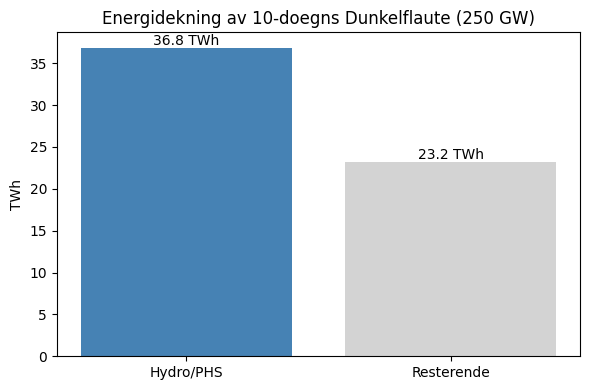

In [4]:
labels = ["Hydro/PHS", "Resterende"]
energies = [min(hydro_energy_available, total_demand_twh), energy_remaining_twh]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, energies, color=["steelblue", "lightgrey"])
ax.set_ylabel("TWh")
ax.set_title("Energidekning av 10-døgns Dunkelflaute (250 GW)")
for i, v in enumerate(energies):
    ax.text(i, v, f"{v:.1f} TWh", ha="center", va="bottom")
plt.tight_layout()
plt.show()


## Læring

- Eksisterende **norsk og svensk vannmagasin** alene har TWh-skala lagring som er **ti til hundretalls ganger større** enn samlet europeisk batteripark. Det er en av grunnene til at hovednotebookens batteritall ser ekstreme ut.
- Det betyr **ikke** at vannkraften kan løse Dunkelflaute alene: det er ikke fri energi, det krever overføringskapasitet (utvidelse 06), og magasinene må ivaretas for vintersesongen.
- En realistisk systemmodell vil **først** bruke hydro/PHS, **deretter** termisk og hydrogen/syntetisk metan, og **batterier til slutt** for korte topper. Hovednotebookens forenkling «batterier dekker alt» er derfor en absurd-grense, ikke en politisk anbefaling.
